## 🧪 Intégration de données météo pro et amateurs

Ce script fusionne plusieurs sources météo hétérogènes pour une analyse en base MongoDB Time Series.

### 🔹 Données professionnelles (JSON)
- Contient :
  - `"stations"` (métadonnées)
  - `"hourly"` (observations)
- Champs traduits : `température_°C`, `pression_hPa`, `vent_moyen_km/h`...

### 🔹 Données amateurs (Excel)
- Onglets = jours (`011024`, `021024`, ...)
- Champs en anglais convertis :
  - `°F` → `°C`, `mph` → `km/h`, `in` → `mm`, etc.
  - Toutes les mesures sont exprimées en unités françaises

### ✅ Résultat
- Données fusionnées
- Clé `type_station` = `"pro"` ou `"amateur"`
- Total : ~4 950 observations
- Prêt pour MongoDB Time Series


In [30]:
# 📦 Imports
import pandas as pd
import json
from pathlib import Path
import re

# 📁 Chemins
json_path = Path("data/Data_Source1_011024-071024.json")
xlsx_lm = Path("data/WeatherUndergroundLaMadeleineFR.xlsx")
xlsx_ic = Path("data/WeatherUndergroundIchtegemBE.xlsx")
output_path = Path("data/observations_flat.json")

# -----------------------------
# 🧼 Helpers robustes
# -----------------------------
def safe_str(x):
    if x is None:
        return None
    s = str(x).replace("\xa0", " ").strip()
    return s if s != "" else None

def safe_float(x):
    s = safe_str(x)
    if s is None:
        return None
    s = s.replace(",", ".")
    m = re.search(r"-?\d+(\.\d+)?", s)
    return float(m.group(0)) if m else None

def safe_int(x):
    f = safe_float(x)
    return int(f) if f is not None else None

def fahrenheit_to_celsius(f):
    return round((f - 32) * 5 / 9, 1)

def parse_sheet_date(sheet_name):
    try:
        return pd.to_datetime(sheet_name, dayfirst=True).strftime("%Y-%m-%d")
    except:
        if re.match(r"\d{6}$", sheet_name):
            d = pd.to_datetime(sheet_name, format="%d%m%y")
            return d.strftime("%Y-%m-%d")
        return None

def parse_time_to_hms(t):
    try:
        return pd.to_datetime(str(t)).strftime("%H:%M:%S")
    except:
        return None

def make_dh_utc(date_str, hms):
    if not date_str or not hms:
        return None
    return f"{date_str}T{hms}Z"

def row_has_measure(row, keys):
    return any(row.get(k) is not None for k in keys)

# -----------------------------
# 🔍 Métadonnées amateurs
# -----------------------------
amateurs_meta = {
    "ILAMAD25": {
        "station_id": "ILAMAD25",
        "station_name": "La Madeleine",
        "ville": "La Madeleine",
        "latitude": 50.659,
        "longitude": 3.07,
        "elevation": 23,
        "hardware": "other",
        "software": "EasyWeatherPro_V5.1.6",
        "type_station": "amateur",
        "source": "Weather Underground (PWS amateur)"
    },
    "IICHTE19": {
        "station_id": "IICHTE19",
        "station_name": "WeerstationBS",
        "ville": "Ichtegem",
        "latitude": 51.092,
        "longitude": 2.999,
        "elevation": 15,
        "hardware": "other",
        "software": "EasyWeatherV1.6.6",
        "type_station": "amateur",
        "source": "Weather Underground (PWS amateur)"
    }
}

# -----------------------------
# 🔄 Traitement des fichiers Excel
# -----------------------------
def clean_excel_sheet(df, sheet_name, station_id):
    date = parse_sheet_date(sheet_name)
    if not date:
        return []
    
    df.columns = [str(c).strip() for c in df.columns]
    data = []

    for _, row in df.iterrows():
        hms = parse_time_to_hms(row.get("Time"))
        dh_utc = make_dh_utc(date, hms)
        if not dh_utc:
            continue

        temp_f = safe_float(row.get("Temperature"))
        dew_f = safe_float(row.get("Dew Point"))

        obs = {
            "station_id": station_id,
            "dh_utc": dh_utc,
            "température_°C": fahrenheit_to_celsius(temp_f) if temp_f is not None else None,
            "point_de_rosée_°C": fahrenheit_to_celsius(dew_f) if dew_f is not None else None,
            "humidité_%": safe_int(row.get("Humidity")),
            "pression_hPa": safe_float(row.get("Pressure")),
            "vent_direction": safe_str(row.get("Wind")),
            "vent_moyen_km/h": safe_float(row.get("Speed")),
            "vent_rafales_km/h": safe_float(row.get("Gust")),
            "pluie_taux_mm/h": safe_float(row.get("Precip. Rate.")),
            "pluie_cumulee_mm": safe_float(row.get("Precip. Accum.")),
            "indice_uv": safe_int(row.get("UV")),
            "rayonnement_solaire_W/m²": safe_float(row.get("Solar"))
        }

        obs.update(amateurs_meta[station_id])

        if row_has_measure(obs, ["température_°C", "pression_hPa", "humidité_%"]):
            data.append(obs)
    return data

def process_excel(path, station_id):
    xl = pd.ExcelFile(path)
    all_data = []
    for sheet in xl.sheet_names:
        df = xl.parse(sheet)
        all_data += clean_excel_sheet(df, sheet, station_id)
    return all_data

# -----------------------------
# 📥 Traitement JSON stations pro
# -----------------------------
with open(json_path, "r", encoding="utf-8") as f:
    json_data = json.load(f)

stations_meta = {
    st["id"]: {
        "station_id": st["id"],
        "station_name": st.get("name"),
        "latitude": st.get("latitude"),
        "longitude": st.get("longitude"),
        "elevation": st.get("elevation"),
        "type_station": "pro",
        "source": st.get("license", {}).get("source")
    }
    for st in json_data.get("stations", []) if isinstance(st, dict) and "id" in st
}

def process_pro_entry(st_id, e):
    try:
        dh = pd.to_datetime(str(e.get("dh_utc")), utc=True).strftime("%Y-%m-%dT%H:%M:%SZ")
    except:
        return None

    obs = {
        "station_id": st_id,
        "dh_utc": dh,
        "température_°C": safe_float(e.get("temperature")),
        "point_de_rosée_°C": safe_float(e.get("point_de_rosee")),
        "humidité_%": safe_int(e.get("humidite")),
        "pression_hPa": safe_float(e.get("pression")),
        "vent_direction": safe_str(e.get("vent_direction")),
        "vent_moyen_km/h": safe_float(e.get("vent_moyen")),
        "vent_rafales_km/h": safe_float(e.get("vent_rafales")),
        "pluie_taux_mm/h": safe_float(e.get("taux_precipitation")),
        "pluie_cumulee_mm": safe_float(e.get("pluie_accumulee")),
        "pluie_1h_mm": safe_float(e.get("pluie_1h")),
        "pluie_3h_mm": safe_float(e.get("pluie_3h")),
        "source": "InfoClimat (stations)"
    }

    obs.update(stations_meta.get(st_id, {}))

    if row_has_measure(obs, ["température_°C", "pression_hPa", "humidité_%"]):
        return obs
    return None

# lecture données horaires
all_json_obs = []
for st_id, series in json_data.get("hourly", {}).items():
    if isinstance(series, list):
        for entry in series:
            if isinstance(entry, dict):
                rec = process_pro_entry(st_id, entry)
                if rec:
                    all_json_obs.append(rec)

# -----------------------------
# 🟰 Fusion & export
# -----------------------------
data = (
    all_json_obs
    + process_excel(xlsx_lm, "ILAMAD25")
    + process_excel(xlsx_ic, "IICHTE19")
)

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)


print(f"✅ {len(data)} observations sauvegardées dans {output_path}")
print(f"   - InfoClimat : {len(json_obs)}")
print(f"   - WU La Madeleine : {len(process_excel(xlsx_lm, 'ILAMAD25'))}")
print(f"   - WU Ichtegem : {len(process_excel(xlsx_ic, 'IICHTE19'))}")



✅ 4950 observations sauvegardées dans data\observations_flat.json
   - InfoClimat : 1143
   - WU La Madeleine : 1908
   - WU Ichtegem : 1899


In [31]:
import pandas as pd
import json
from IPython.display import display


In [32]:


# Charger les données fusionnées
with open("data/observations_flat.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# --- Typage & nettoyage ---
df["dh_utc"] = pd.to_datetime(df["dh_utc"], errors="coerce", utc=True)
df["température_°C"] = pd.to_numeric(df.get("température_°C"), errors="coerce")
df["pression_hPa"] = pd.to_numeric(df.get("pression_hPa"), errors="coerce")
df["humidité_%"] = pd.to_numeric(df.get("humidité_%"), errors="coerce")

# Ville : prioritaire = champ 'ville' (stations amateurs), sinon fallback pro
# Si tu n'as pas "ville" pour les stations pro, on met le station_name ou "Inconnu"
if "ville" not in df.columns:
    df["ville"] = None

df["ville"] = df["ville"].fillna(df.get("station_name")).fillna("Inconnu")

# Jour (UTC)
df["jour"] = df["dh_utc"].dt.date

# --- Filtre qualité température (évite moyenne absurde) ---
TEMP_MIN, TEMP_MAX = -20, 45
df_temp = df.dropna(subset=["dh_utc", "température_°C"]).copy()
df_temp = df_temp[(df_temp["température_°C"] >= TEMP_MIN) & (df_temp["température_°C"] <= TEMP_MAX)]

# --- Stats par ville puis par jour ---
agg = (
    df_temp
    .groupby(["ville", "jour"], as_index=False)
    .agg(
        nb_obs=("température_°C", "size"),
        temp_moy=("température_°C", "mean"),
        temp_med=("température_°C", "median"),
        temp_min=("température_°C", "min"),
        temp_max=("température_°C", "max"),
    )
)

agg["temp_moy"] = agg["temp_moy"].round(2)
agg["temp_med"] = agg["temp_med"].round(2)
agg["temp_min"] = agg["temp_min"].round(2)
agg["temp_max"] = agg["temp_max"].round(2)

print("🌡️ Température — stats par ville et par jour (filtrées sur valeurs plausibles)")
display(agg.sort_values(["ville", "jour"]))

# --- Diagnostic : valeurs extrêmes AVANT filtre (pour comprendre le 43.5°C) ---
extremes = (
    df.dropna(subset=["dh_utc", "température_°C"])
      .sort_values("température_°C")
      .loc[:, ["dh_utc", "station_id", "station_name", "ville", "type_station", "température_°C"]]
)

print("\n🧪 10 températures les plus basses (avant filtre) :")
display(extremes.head(10))

print("\n🧪 10 températures les plus hautes (avant filtre) :")
display(extremes.tail(10))


🌡️ Température — stats par ville et par jour (filtrées sur valeurs plausibles)


,ville,jour,nb_obs,temp_moy,temp_med,temp_min,temp_max
0,Armentières,2024-10-05,144,10.16,10.30,3.4,17.2
1,Armentières,2024-10-06,144,12.54,13.35,8.6,15.8
2,Armentières,2024-10-07,73,14.36,14.30,11.3,18.4
3,Bergues,2024-10-05,144,11.22,10.15,6.3,17.8
4,Bergues,2024-10-06,144,12.62,13.70,8.5,16.8
5,Bergues,2024-10-07,73,14.44,14.10,12.6,18.6
6,Hazebrouck,2024-10-05,144,9.53,8.90,2.7,17.4
7,Hazebrouck,2024-10-06,144,12.26,13.60,8.0,15.6
8,Hazebrouck,2024-10-07,73,14.15,13.80,11.7,18.2
9,Ichtegem,2024-10-01,288,12.82,12.70,10.5,15.7



🧪 10 températures les plus basses (avant filtre) :


,dh_utc,station_id,station_name,ville,type_station,température_°C
4001,2024-10-04 07:49:00+00:00,IICHTE19,WeerstationBS,Ichtegem,amateur,2.5
4000,2024-10-04 07:44:00+00:00,IICHTE19,WeerstationBS,Ichtegem,amateur,2.6
819,2024-10-05 06:10:00+00:00,STATIC0010,Hazebrouck,Hazebrouck,pro,2.7
818,2024-10-05 06:00:00+00:00,STATIC0010,Hazebrouck,Hazebrouck,pro,2.7
817,2024-10-05 05:50:00+00:00,STATIC0010,Hazebrouck,Hazebrouck,pro,2.8
4002,2024-10-04 07:54:00+00:00,IICHTE19,WeerstationBS,Ichtegem,amateur,2.8
820,2024-10-05 06:20:00+00:00,STATIC0010,Hazebrouck,Hazebrouck,pro,2.8
3999,2024-10-04 07:39:00+00:00,IICHTE19,WeerstationBS,Ichtegem,amateur,2.8
816,2024-10-05 05:40:00+00:00,STATIC0010,Hazebrouck,Hazebrouck,pro,2.8
821,2024-10-05 06:30:00+00:00,STATIC0010,Hazebrouck,Hazebrouck,pro,2.9



🧪 10 températures les plus hautes (avant filtre) :


,dh_utc,station_id,station_name,ville,type_station,température_°C
3049,2024-10-07 14:54:00+00:00,ILAMAD25,La Madeleine,La Madeleine,amateur,18.5
3043,2024-10-07 14:24:00+00:00,ILAMAD25,La Madeleine,La Madeleine,amateur,18.5
781,2024-10-07 12:00:00+00:00,000R5,Bergues,Bergues,pro,18.6
1601,2024-10-02 14:14:00+00:00,ILAMAD25,La Madeleine,La Madeleine,amateur,18.6
4946,2024-10-07 14:34:00+00:00,IICHTE19,WeerstationBS,Ichtegem,amateur,18.6
4947,2024-10-07 14:39:00+00:00,IICHTE19,WeerstationBS,Ichtegem,amateur,18.7
3042,2024-10-07 14:19:00+00:00,ILAMAD25,La Madeleine,La Madeleine,amateur,18.8
4948,2024-10-07 14:44:00+00:00,IICHTE19,WeerstationBS,Ichtegem,amateur,19.1
4949,2024-10-07 14:49:00+00:00,IICHTE19,WeerstationBS,Ichtegem,amateur,19.1
1602,2024-10-02 14:19:00+00:00,ILAMAD25,La Madeleine,La Madeleine,amateur,19.3


## Script unique d’audit & d’analyse des observations météo (avant import MongoDB)

Ce script charge `data/observations_flat.json`, met en forme les données (types, dates, ville),
puis exécute une série de contrôles et d’analyses pour évaluer la qualité du jeu de données.

### Ce que le script fait

1) **Chargement & typage**
- Lit le JSON fusionné (liste d’observations)
- Convertit `dh_utc` en datetime UTC
- Convertit en numériques : température, pression, humidité, vent, pluie…

2) **Normalisation “ville”**
- Utilise la colonne `ville` si elle existe (stations amateurs)
- Sinon essaie d’extraire une ville depuis `station_name` (ex: “Lille-Lesquin” → “Lille”)
- Sinon met “Inconnu”

3) **Contrôles de qualité (QC)**
- Taux de valeurs manquantes par variable
- Valeurs **hors plages plausibles** (température, humidité, pression, vent, pluie)
- Stations les plus “problématiques” (% d’anomalies)
- Doublons sur la clé métier (`station_id`, `dh_utc`)
- Timestamps non parseables

4) **Couverture temporelle**
- Pas de temps dominant (minutes) par station
- Plus grand trou temporel (gap) par station
- Min/Max dates par station

5) **Analyses “météo” utiles**
- **Stats par ville et par jour** (moyenne/mediane/min/max de température)
- Amplitude thermique journalière (max-min) par ville
- Comparaison **pro vs amateur** (moyennes/mediane/écart-type)
- Vent : direction la plus fréquente + vitesses moyennes
- Pluie : détection de cas incohérents (taux fort avec cumul nul, etc.)
- Détection “capteur bloqué” (température identique trop longtemps)

### Sorties
Le script affiche des tableaux (DataFrames) directement dans Jupyter.



# 🧼 Nettoyage & Validation des Observations Météo

Ce script charge les données du fichier `observations_flat.json`, vérifie leur cohérence (format de date, types, plages plausibles), identifie les valeurs aberrantes (outliers) et produit deux fichiers :

- `observations_def.json` : les observations valides, prêtes à être importées dans MongoDB (format JSON, UTF-8, encodage lisible, types simples)
- `anomalies.json` : les observations contenant au moins une valeur hors plage, pour revue manuelle ou exclusion

## 🧪 Tests appliqués

- **Vérification du timestamp `dh_utc`** : parsing ISO + doublons
- **Contrôle des plages** (ex: température -25 à 45°C, humidité 0-100%, etc.)
- **Détection de valeurs manquantes**
- **Tri des stations les plus problématiques**

Toutes les colonnes numériques sont converties, et les NaN sont remplacés par des chaînes vides dans le fichier final.

Ce nettoyage est une étape cruciale avant l'import dans une base **MongoDB Time-Series**, afin de garantir une qualité et une cohérence des données.


In [37]:
# 📦 Imports
import pandas as pd
import json
import numpy as np
import re
from pathlib import Path
from IPython.display import display

# 📁 Paramètres
INPUT_PATH = Path("data/observations_flat.json")
OUTPUT_CLEAN = Path("data/observations_def.json")
ANOMALIES_PATH = Path("data/anomalies.json")

NUM_COLS = [
    "température_°C", "point_de_rosée_°C", "humidité_%", "pression_hPa",
    "vent_moyen_km/h", "vent_rafales_km/h", "pluie_taux_mm/h", "pluie_cumulee_mm",
    "indice_uv", "rayonnement_solaire_W/m²", "pluie_1h_mm", "pluie_3h_mm"
]

RANGES = {
    "température_°C": (-25, 45),
    "humidité_%": (0, 100),
    # "pression_hPa": (850, 1100),
    "vent_moyen_km/h": (0, 200),
    "vent_rafales_km/h": (0, 250),
    "pluie_taux_mm/h": (0, 200),
    "pluie_cumulee_mm": (0, 5000),
}

# 🧼 Helper JSON-friendly
def serialize_for_json(df):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].dt.strftime("%Y-%m-%dT%H:%M:%SZ")
        elif df[col].dtype == "object":
            df[col] = df[col].apply(lambda x: x.isoformat() if hasattr(x, "isoformat") else x)
    return df

def extract_ville_from_station_name(name):
    if name is None: return None
    s = str(name).strip()
    s = re.sub(r"\(.*?\)", "", s).strip()
    if "-" in s:
        return s.split("-")[0].strip()
    return s

# 1️⃣ Chargement
with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(f"✅ Chargé {len(df)} observations depuis {INPUT_PATH}")

# 2️⃣ Typage
df["dh_utc"] = pd.to_datetime(df["dh_utc"], errors="coerce", utc=True)

for col in NUM_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Ville
if "ville" not in df.columns:
    df["ville"] = df["station_name"].map(extract_ville_from_station_name)
else:
    df["ville"] = df["ville"].fillna(df["station_name"].map(extract_ville_from_station_name))

df["ville"] = df["ville"].fillna("Inconnu")

# Date/heure
df["jour"] = df["dh_utc"].dt.date
df["heure"] = df["dh_utc"].dt.hour

# 3️⃣ Anomalies par plage
mask_anomaly = pd.Series(False, index=df.index)
anomalies_info = []

for col, (lo, hi) in RANGES.items():
    if col in df.columns:
        s = df[col]
        out = s.notna() & ((s < lo) | (s > hi))
        mask_anomaly |= out
        anomalies_info.append({
            "champ": col,
            "nb_total": int(s.notna().sum()),
            "nb_anomalies": int(out.sum()),
            "% anomalies": round(100 * out.sum() / max(s.notna().sum(), 1), 2),
            "min": s.min(),
            "max": s.max()
        })

anomalies_df = df[mask_anomaly]
df_clean = df[~mask_anomaly]

# 4️⃣ Sauvegarde JSON
anomalies_dict = serialize_for_json(anomalies_df).to_dict(orient="records")
clean_dict = serialize_for_json(df_clean).to_dict(orient="records")

with open(ANOMALIES_PATH, "w", encoding="utf-8") as f:
    json.dump(anomalies_dict, f, indent=2, ensure_ascii=False)

with open(OUTPUT_CLEAN, "w", encoding="utf-8") as f:
    json.dump(clean_dict, f, indent=2, ensure_ascii=False)

print(f"📤 Anomalies : {len(anomalies_dict)} observations exportées vers {ANOMALIES_PATH}")
print(f"📤 Données propres : {len(clean_dict)} observations exportées vers {OUTPUT_CLEAN}")

# 5️⃣ Analyse descriptive
print("\n📊 Répartition par type de station")
display(df["type_station"].value_counts())

print("\n📊 Répartition par ville")
display(df["ville"].value_counts().head(20))

print("\n📈 Statistiques sur la température (valeurs plausibles uniquement)")
df_temp = df_clean.dropna(subset=["température_°C"])
display(df_temp.groupby("ville")["température_°C"].agg(["count", "mean", "median", "min", "max"]).round(2))

print("\n⚠️ Statistiques anomalies par champ")
display(pd.DataFrame(anomalies_info).sort_values("% anomalies", ascending=False).reset_index(drop=True))


✅ Chargé 4950 observations depuis data\observations_flat.json
📤 Anomalies : 0 observations exportées vers data\anomalies.json
📤 Données propres : 4950 observations exportées vers data\observations_def.json

📊 Répartition par type de station


amateur    3807
pro        1143
Name: type_station, dtype: int64


📊 Répartition par ville


La Madeleine    1908
Ichtegem        1899
Armentières      361
Bergues          361
Hazebrouck       361
Lille             60
Name: ville, dtype: int64


📈 Statistiques sur la température (valeurs plausibles uniquement)


,count,mean,median,min,max
ville,,,,,
Armentières,361,11.96,13.1,3.4,18.4
Bergues,361,12.43,13.3,6.3,18.6
Hazebrouck,361,11.56,12.9,2.7,18.2
Ichtegem,1899,11.39,11.9,2.5,19.1
La Madeleine,1908,11.91,12.4,4.8,19.3
Lille,60,11.80,12.8,5.0,17.6



⚠️ Statistiques anomalies par champ


,champ,nb_total,nb_anomalies,% anomalies,min,max
0,température_°C,4950,0,0.0,2.5,19.30
1,humidité_%,4950,0,0.0,49.0,100.00
2,vent_moyen_km/h,4950,0,0.0,0.0,25.20
3,vent_rafales_km/h,3867,0,0.0,0.0,46.80
4,pluie_taux_mm/h,3807,0,0.0,0.0,0.35
5,pluie_cumulee_mm,3807,0,0.0,0.0,0.19


In [43]:
import json
import math

INPUT = "data/observations_def.json"
OUTPUT = "data/observations_timeseries.jsonl"

# 1. Charger la liste principale
with open(INPUT, 'r', encoding='utf-8') as f:
    raw = json.load(f)

if not isinstance(raw, list) or len(raw) == 0:
    raise ValueError("❌ Le fichier JSON ne contient pas une liste d'observations.")

# 2. Nettoyer et formater chaque observation
valid = 0
skipped = 0

with open(OUTPUT, "w", encoding="utf-8") as fout:
    for obs in raw:
        try:
            # Remplacer les NaN → null
            for k, v in obs.items():
                if isinstance(v, float) and math.isnan(v):
                    obs[k] = None

            # Vérifier et convertir dh_utc
            if "dh_utc" in obs and isinstance(obs["dh_utc"], str):
                obs["dh_utc"] = {"$date": obs["dh_utc"]}
                json.dump(obs, fout, ensure_ascii=False)
                fout.write("\n")
                valid += 1
            else:
                skipped += 1

        except Exception as e:
            print(f"⚠️ Observation ignorée : {e}")
            skipped += 1

print(f"✅ {valid} observations valides exportées dans {OUTPUT}")
print(f"⚠️ {skipped} ignorées")


✅ 4950 observations valides exportées dans data/observations_timeseries.jsonl
⚠️ 0 ignorées


In [54]:
from pymongo import MongoClient
import polars as pl
import matplotlib.pyplot as plt


C:\Users\karap\AppData\Local\Temp\ipykernel_19036\3882229710.py:53: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from current font.
  plt.tight_layout()
c:\Users\karap\anaconda3\envs\datascience1\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


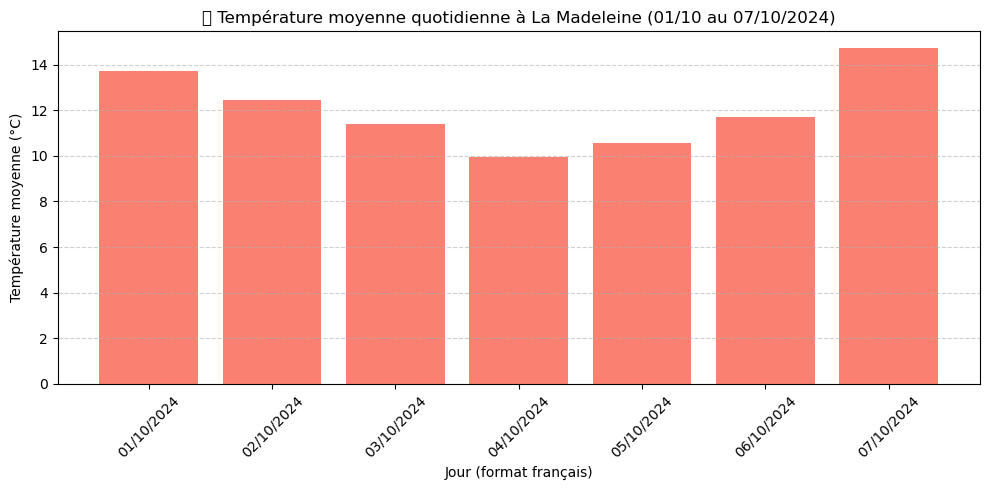

In [60]:
# 📦 Connexion à MongoDB
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt

# Connexion à MongoDB local
client = MongoClient("mongodb://localhost:27017/")
db = client["GreenCoop"]
collection = db["ObsProEtAmateur"]

# 📊 Pipeline d’agrégation
pipeline = [
    {
        "$match": {
            "ville": "La Madeleine",
            "jour": {"$gte": "2024-10-01", "$lte": "2024-10-07"}
        }
    },
    {
        "$group": {
            "_id": "$jour",
            "avgTemp": {"$avg": "$température_°C"}
        }
    },
    {
        "$project": {
            "_id": 0,
            "jour": "$_id",
            "avgTemp": {"$round": ["$avgTemp", 2]}
        }
    }
]

# ⚙️ Exécuter la requête
results = list(collection.aggregate(pipeline))

# 🧼 Mise en forme avec pandas
df = pd.DataFrame(results)
df['jour'] = pd.to_datetime(df['jour'])  # Conversion en datetime
df = df.sort_values("jour")

# Ajout d'une colonne pour l'affichage en français
df['jour_fr'] = df['jour'].dt.strftime('%d/%m/%Y')

# 📈 Affichage du graphique
plt.figure(figsize=(10, 5))
plt.bar(df['jour_fr'], df['avgTemp'], color='salmon')
plt.title("🌡️ Température moyenne quotidienne à La Madeleine (01/10 au 07/10/2024)")
plt.xlabel("Jour (format français)")
plt.ylabel("Température moyenne (°C)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [61]:
from pymongo import MongoClient
import pandas as pd

# Connexion à MongoDB
client = MongoClient("mongodb://localhost:27017/")
db = client["GreenCoop"]
collection = db["ObsProEtAmateur"]

# Pipeline d'agrégation pour récupérer toutes les villes distinctes
pipeline = [
    {"$match": {"ville": {"$exists": True, "$ne": None, "$ne": ""}}},
    {"$group": {"_id": "$ville", "count": {"$sum": 1}}},
    {"$sort": {"_id": 1}}  # Tri alphabétique des villes
]

# Exécution de la requête
results = list(collection.aggregate(pipeline))

# Conversion en DataFrame
df_villes = pd.DataFrame(results)
df_villes.columns = ["ville", "nb_observations"]

# Affichage
print("✅ Liste des villes avec données météo :")
display(df_villes)


✅ Liste des villes avec données météo :


,ville,nb_observations
0,Armentières,361
1,Bergues,361
2,Hazebrouck,361
3,Ichtegem,1899
4,La Madeleine,1908
5,Lille,60


In [63]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt

# Connexion MongoDB
client = MongoClient("mongodb://localhost:27017/")
db = client["GreenCoop"]
collection = db["ObsProEtAmateur"]

# 🔍 Pipeline général (pour toutes les stations)
pipeline = [
    {
        "$group": {
            "_id": {
                "type_station": "$type_station",
                "station_id": "$station_id",
                "ville": "$ville",
                "jour": "$jour"
            },
            "nb_obs": {"$sum": 1}
        }
    },
    {"$sort": {"_id.station_id": 1, "_id.jour": 1}}
]

# 📦 Exécution
results = list(collection.aggregate(pipeline))

# 🐼 DataFrame
df = pd.DataFrame([{
    "type_station": r["_id"]["type_station"],
    "station_id": r["_id"]["station_id"],
    "ville": r["_id"]["ville"],
    "jour": r["_id"]["jour"],
    "nb_obs": r["nb_obs"]
} for r in results])

# ✅ Formatage des dates si besoin
df["jour"] = pd.to_datetime(df["jour"])

# 👀 Aperçu groupé par station
print("📊 Observations par STATION :")
display(df.sort_values(by=["station_id", "jour"]))

# 🖼️ Exemple de graphe : une station amateur spécifique
station_exemple = df[(df["type_station"] == "amateur") & (df["station_id"] == "12345")]  # <- adapte à ton cas
if not station_exemple.empty:
    plt.figure(figsize=(10, 4))
    plt.plot(station_exemple["jour"], station_exemple["nb_obs"], marker="o")
    plt.title(f"📈 Nb observations par jour - Station {station_exemple['station_id'].iloc[0]}")
    plt.xlabel("Date")
    plt.ylabel("Nb d'observations")
    plt.grid(True)
    plt.show()


📊 Observations par STATION :


,type_station,station_id,ville,jour,nb_obs
0,pro,00052,Armentières,2024-10-05,144
1,pro,00052,Armentières,2024-10-06,144
2,pro,00052,Armentières,2024-10-07,73
3,pro,000R5,Bergues,2024-10-05,144
4,pro,000R5,Bergues,2024-10-06,144
5,pro,000R5,Bergues,2024-10-07,73
6,pro,07015,Lille,2024-10-05,24
7,pro,07015,Lille,2024-10-06,24
8,pro,07015,Lille,2024-10-07,12
9,amateur,IICHTE19,Ichtegem,2024-10-01,288




# 📊 Analyse météo avancée avec MongoDB Time Series

## 🧩 Objectif

Détecter les jours où la **température maximale dépasse 18°C** pour chaque **station amateur**, sur une période donnée, en exploitant les capacités des **collections Time Series de MongoDB**.

---

## ⚙️ Pourquoi utiliser les Time Series ?

Les **collections Time Series de MongoDB** sont conçues pour stocker des données structurées autour d’un champ `timeField` (ici `dh_utc`) :

| Atout                      | Description                                                                                               |
| -------------------------- | --------------------------------------------------------------------------------------------------------- |
| ✅ Stockage optimisé        | MongoDB regroupe automatiquement les documents dans des "buckets" temporels pour réduire l'espace disque. |
| ⚡ Interrogation efficace   | Les champs temporels sont indexés automatiquement, accélérant les requêtes par période.                   |
| 📉 Analytique facilitée    | Opérateurs comme `$dateTrunc`, `$densify`, `$setWindowFields` permettent des analyses temporelles fines.  |
| 🧠 Agrégation intelligente | Moins de documents à parcourir → pipelines plus rapides et moins coûteux.                                 |

---

## 🔍 Requête ciblée : Températures extrêmes par station

### 💡 Ce que l'on cherche :

> **Pour chaque station amateur**, quels sont les **jours où la température maximale a dépassé 18°C** pendant la semaine du 1er au 7 octobre 2024 ?

---

## 🧪 Script Python (MongoDB + pandas)

```python
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt

# Connexion à la base MongoDB locale
client = MongoClient("mongodb://localhost:27017/")
coll = client["GreenCoop"]["ObsProEtAmateur"]

# 🧠 Pipeline d'agrégation MongoDB Time Series
pipeline = [
    {"$match": {
        "type_station": "amateur",
        "dh_utc": {
            "$gte": pd.to_datetime("2024-10-01"),
            "$lt": pd.to_datetime("2024-10-08")
        },
        "température_°C": {"$ne": None}
    }},
    {"$group": {
        "_id": {
            "station_id": "$station_id",
            "jour": {"$dateTrunc": {"date": "$dh_utc", "unit": "day"}}
        },
        "max_temp": {"$max": "$température_°C"},
        "ville": {"$first": "$ville"}
    }},
    {"$match": {"max_temp": {"$gt": 30}}},
    {"$sort": {"_id.jour": 1}}
]

results = list(coll.aggregate(pipeline))

# 📊 Chargement des résultats dans un DataFrame pandas
df = pd.DataFrame([{
    "station_id": r["_id"]["station_id"],
    "jour": r["_id"]["jour"],
    "ville": r["ville"],
    "température_max": r["max_temp"]
} for r in results])

# 🎨 Affichage graphique
if not df.empty:
    df["jour"] = pd.to_datetime(df["jour"])
    df["jour_fmt"] = df["jour"].dt.strftime("%d/%m/%Y")  # Format français

    df.plot(
        x="jour_fmt", y="température_max", kind="bar", 
        color="tomato", legend=False, figsize=(10, 5)
    )
    plt.title("🌡️ Jours > 30°C par station amateur (01/10–07/10/2024)")
    plt.xlabel("Jour")
    plt.ylabel("Température max (°C)")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("✅ Aucune température > 30°C détectée sur cette période pour les stations amateurs.")
```

---

## 📈 Résultat attendu

* Un **bar chart** avec :

  * L’axe X = les **jours (format DD/MM/YYYY)**.
  * L’axe Y = les **températures maximales** par station.
  * Une barre pour chaque station ayant dépassé 18°C un jour donné.

---

## 🧠 Ce que cela démontre

| Élément                | Utilisation                                                      |
| ---------------------- | ---------------------------------------------------------------- |
| `dh_utc`               | Sert de champ temporel pour la Time Series                       |
| `$dateTrunc`           | Regroupe les mesures **par jour**                                |
| `$max`                 | Calcule la température la plus haute dans la journée             |
| `$match` (post-$group) | Focalise uniquement sur les journées chaudes                     |
| Time Series            | Permet des **recherches efficaces et compressées** dans le temps |

---

## ➕ Variantes possibles

* Température **moyenne** par jour (`$avg`).
* Comparaison entre stations **pro** et **amateur**.
* Nombre d’observations par heure/jour/station (`$count`, `$densify`).
* Analyse de **saisonnalité**, **pics de vent**, **fortes pluies**, etc.

Souhaites-tu que je t’écrive une de ces variantes ?


  station_id       jour         ville  température_max
0   ILAMAD25 2024-10-02  La Madeleine             19.3
1   IICHTE19 2024-10-07      Ichtegem             19.1
2   ILAMAD25 2024-10-07  La Madeleine             18.8


C:\Users\karap\AppData\Local\Temp\ipykernel_19036\1582220318.py:49: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from current font.
  plt.tight_layout()
c:\Users\karap\anaconda3\envs\datascience1\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


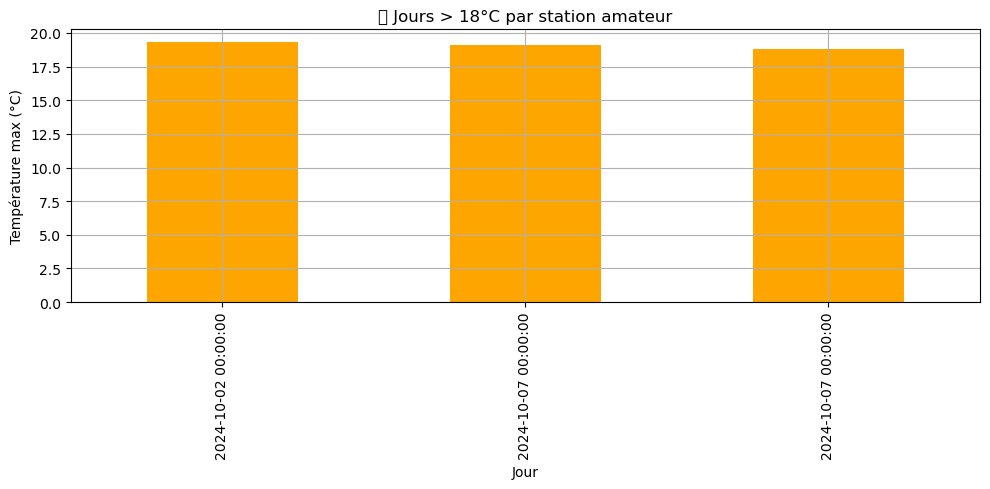

In [68]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt

client = MongoClient("mongodb://localhost:27017/")
coll = client["GreenCoop"]["ObsProEtAmateur"]

# Pipeline
pipeline = [
    {"$match": {
        "type_station": "amateur",
        "dh_utc": {
            "$gte": pd.to_datetime("2024-10-01"),
            "$lt": pd.to_datetime("2024-10-08")
        },
        "température_°C": {"$ne": None}
    }},
    {"$group": {
        "_id": {
            "station_id": "$station_id",
            "jour": {"$dateTrunc": {"date": "$dh_utc", "unit": "day"}}
        },
        "max_temp": {"$max": "$température_°C"},
        "ville": {"$first": "$ville"}
    }},
    {"$match": {"max_temp": {"$gt": 18}}},
    {"$sort": {"_id.jour": 1}}
]

results = list(coll.aggregate(pipeline))

# ➕ DataFrame
df = pd.DataFrame([{
    "station_id": r["_id"]["station_id"],
    "jour": r["_id"]["jour"],
    "ville": r["ville"],
    "température_max": r["max_temp"]
} for r in results])

# 📊 Affichage
if not df.empty:
    print(df)
    df["jour"] = pd.to_datetime(df["jour"])
    df.plot(x="jour", y="température_max", kind="bar", legend=False, color="orange", figsize=(10, 5))
    plt.title("🌡️ Jours > 18°C par station amateur")
    plt.xlabel("Jour")
    plt.ylabel("Température max (°C)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Aucune température > 18°C détectée sur la période pour les stations amateurs.")




### ⏱️ Pourquoi utiliser une collection **Time Series** dans MongoDB ?

MongoDB propose un modèle **natif pour les séries temporelles** depuis la version 5.0, optimisé pour les données collectées dans le temps à intervalles réguliers, comme :

* Les températures horaires
* Les relevés de capteurs
* Les données météo, énergie, IoT, etc.

---

### ✅ Avantages des **collections time series**

| Avantage                             | Explication                                                                                                    |
| ------------------------------------ | -------------------------------------------------------------------------------------------------------------- |
| 📦 **Stockage optimisé**             | Les documents sont automatiquement regroupés par intervalle de temps → compression plus efficace.              |
| 🚀 **Performances accrues**          | Les requêtes sur les champs `timeField` (ex. : `dh_utc`) sont très rapides grâce à des optimisations internes. |
| 📊 **Indexation automatique**        | MongoDB crée automatiquement des index optimisés sur la date pour faciliter l’analyse temporelle.              |
| 🧠 **Requêtes agrégées puissantes**  | Tu peux facilement grouper par heure, jour, semaine, mois, etc. grâce à `$group` et `$dateTrunc`.              |
| 🔒 **Moins de maintenance manuelle** | Pas besoin de gérer toi-même les stratégies de partition ou les rollups. Mongo gère ça automatiquement.        |

---

### 🧪 Exemple : Visualisation heure par heure des températures

Dans notre projet, chaque observation météo contient une date (`dh_utc`) :
✅ Elle est utilisée comme `timeField` dans notre collection time series.

Cela nous permet de :

* Grouper facilement les données **par heure** ou **par jour**
* Filtrer très rapidement une période précise
* Visualiser la **courbe de température** en quelques lignes de code

```js
// Exemple MongoDB Aggregation Pipeline
[
  { $match: { dh_utc: { $gte: ISODate("2024-10-01"), $lt: ISODate("2024-10-02") } } },
  { $group: {
      _id: { heure: { $hour: "$dh_utc" }, ville: "$ville" },
      temp_moy: { $avg: "$température_°C" }
  }},
  ...
]
```

---

### 🧭 En résumé

Les **collections time series** sont idéales pour :

* Les **données météo**, capteurs, IoT, énergie, trafic...
* Les analyses **temps réel** ou historiques
* Réduire le **coût de stockage** et accélérer les **requêtes analytiques**

MongoDB te permet de combiner **flexibilité du NoSQL** avec des **optimisations de séries temporelles**, le tout avec une syntaxe familière !

---

Souhaitez-tu que je t’ajoute un exemple supplémentaire avec `$dateTrunc` ou des visualisations par semaine ou par station ?


C:\Users\karap\AppData\Local\Temp\ipykernel_19036\1402636913.py:57: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from current font.
  plt.tight_layout()
c:\Users\karap\anaconda3\envs\datascience1\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


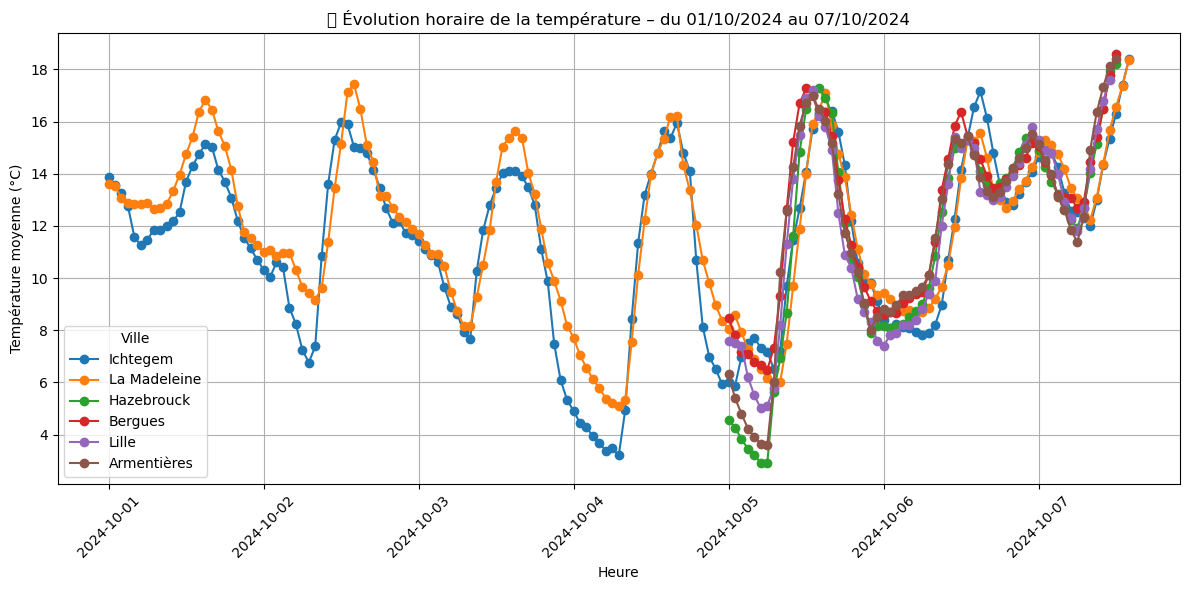

In [74]:


# 📡 Connexion à MongoDB local
client = MongoClient("mongodb://localhost:27017/")
coll = client["GreenCoop"]["ObsProEtAmateur"]

# 📦 Pipeline d'agrégation pour regrouper par ville et heure
pipeline = [
    {"$match": {
        "dh_utc": {
            "$gte": pd.to_datetime("2024-10-01T00:00:00Z"),
            "$lt": pd.to_datetime("2024-10-08T00:00:00Z")
        },
        "température_°C": {"$ne": None}
    }},
    {"$addFields": {
        "heure": {
            "$dateTrunc": {
                "date": "$dh_utc",
                "unit": "hour"
            }
        }
    }},
    {"$group": {
        "_id": {"ville": "$ville", "heure": "$heure"},
        "temp_moy": {"$avg": "$température_°C"}
    }},
    {"$project": {
        "_id": 0,
        "ville": "$_id.ville",
        "heure": "$_id.heure",
        "temp_moy": {"$round": ["$temp_moy", 2]}
    }},
    {"$sort": {"heure": 1}}
]

# 🔍 Exécution de la requête
results = list(coll.aggregate(pipeline))

# 🐼 Chargement dans un DataFrame
df = pd.DataFrame(results)
df["heure"] = pd.to_datetime(df["heure"])

# 🎨 Affichage des courbes par ville
plt.figure(figsize=(12, 6))
for ville in df["ville"].unique():
    data_ville = df[df["ville"] == ville].sort_values("heure")
    plt.plot(
        data_ville["heure"], data_ville["temp_moy"], 
        marker='o', label=ville
    )

plt.title("🌡️ Évolution horaire de la température – du 01/10/2024 au 07/10/2024")
plt.xlabel("Heure")
plt.ylabel("Température moyenne (°C)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="Ville")
plt.tight_layout()
plt.show()


Tester **l'intégrité des données après migration vers MongoDB**, en particulier pour un jeu de données météorologiques comme le tien (mesures horodatées, stations, etc.).

---

## ✅ **Objectifs du test d’intégrité post-migration**

Tu veux t'assurer que :

1. **Toutes les colonnes attendues sont présentes**
2. **Les types sont corrects** (ex. `température_°C` est bien un float, `dh_utc` est une date)
3. **Il n’y a pas de valeurs manquantes critiques**
4. **Il n’y a pas de doublons** (même `station_id` + `dh_utc`)
5. **La volumétrie attendue est respectée** (nombre de documents similaires à l’original)
6. **Les valeurs sont dans des plages plausibles** (températures, etc.)
7. **Des champs-clés comme `dh_utc`, `station_id`, `type_station` existent et sont cohérents**

---

## 💡 **Démarche proposée (étape par étape)**

| Étape                              | Action                                           |
| ---------------------------------- | ------------------------------------------------ |
| 1️⃣ Connexion à MongoDB            | Connexion à la collection migrée                 |
| 2️⃣ Extraction des documents       | On récupère les données dans un `DataFrame`      |
| 3️⃣ Vérifications structurelles    | Colonnes, types, présence de champs              |
| 4️⃣ Doublons                       | Détection sur `station_id + dh_utc`              |
| 5️⃣ Données manquantes             | % de valeurs nulles par champ                    |
| 6️⃣ Contrôle des plages de valeurs | Température, humidité, pression…                 |
| 7️⃣ Statistiques                   | Volume total, nombre de stations, plages de date |

---

## 🐍 **Script Python pour test d’intégrité post-migration**

```python
# 📦 Imports
import pandas as pd
from pymongo import MongoClient
from IPython.display import display

# 🔌 Connexion MongoDB
client = MongoClient("mongodb://localhost:27017")
db = client["meteo"]  # à adapter
collection = db["observations"]  # à adapter

# 1️⃣ Lecture MongoDB -> DataFrame
docs = list(collection.find({}, {"_id": 0}))  # on ignore le _id Mongo
df = pd.DataFrame(docs)

print(f"✅ {len(df)} documents récupérés de MongoDB")

# 2️⃣ Contrôle structure
expected_cols = [
    "dh_utc", "station_id", "station_name", "type_station", "ville",
    "température_°C", "point_de_rosée_°C", "humidité_%", "pression_hPa",
    "vent_moyen_km/h", "vent_rafales_km/h", "pluie_taux_mm/h", "pluie_cumulee_mm",
    "pluie_1h_mm", "pluie_3h_mm", "indice_uv", "rayonnement_solaire_W/m²"
]

missing_cols = [c for c in expected_cols if c not in df.columns]
print("❌ Colonnes manquantes :", missing_cols if missing_cols else "✅ Aucune")

# 3️⃣ Typage (vérifie si convertibles au bon type)
df["dh_utc"] = pd.to_datetime(df["dh_utc"], errors="coerce", utc=True)

num_cols = [c for c in expected_cols if "°C" in c or "hPa" in c or "mm" in c or "W/m²" in c or "_%" in c]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 4️⃣ Doublons
nb_dups = df.duplicated(subset=["station_id", "dh_utc"]).sum()
print(f"🔁 Doublons (station_id + dh_utc) : {nb_dups}")

# 5️⃣ Valeurs manquantes (% par champ)
print("\n📉 Valeurs manquantes (% top 10) :")
display((df.isna().mean() * 100).round(2).sort_values(ascending=False).head(10))

# 6️⃣ Contrôle des plages plausibles
ranges = {
    "température_°C": (-25, 45),
    "humidité_%": (0, 100),
    "pression_hPa": (850, 1100),
    "vent_moyen_km/h": (0, 200),
    "vent_rafales_km/h": (0, 250),
    "pluie_taux_mm/h": (0, 200),
    "pluie_cumulee_mm": (0, 5000),
}

print("\n📏 Contrôle des plages plausibles :")
for col, (lo, hi) in ranges.items():
    if col in df.columns:
        s = df[col].dropna()
        outliers = ((s < lo) | (s > hi)).sum()
        total = len(s)
        print(f"{col} : {outliers}/{total} hors plage ({round(outliers/total*100, 2)}%)")

# 7️⃣ Statistiques globales
print("\n📊 Statistiques globales")
print("Stations :", df["station_id"].nunique())
print("Villes :", df["ville"].nunique())
print("Type stations :", df["type_station"].value_counts(dropna=False).to_dict())
print("Période :", df["dh_utc"].min(), "→", df["dh_utc"].max())
```




In [2]:
# 📦 Imports
import pandas as pd
from pymongo import MongoClient
from IPython.display import display

In [3]:

# 🔌 Connexion MongoDB
client = MongoClient("mongodb://localhost:27017")
db = client["GreenCoop"]  # à adapter
collection = db["ObsProEtAmateur"]  # à adapter

# 1️⃣ Lecture MongoDB -> DataFrame
docs = list(collection.find({}, {"_id": 0}))  # on ignore le _id Mongo
df = pd.DataFrame(docs)

print(f"✅ {len(df)} documents récupérés de MongoDB")

# 2️⃣ Contrôle structure
expected_cols = [
    "dh_utc", "station_id", "station_name", "type_station", "ville",
    "température_°C", "point_de_rosée_°C", "humidité_%", "pression_hPa",
    "vent_moyen_km/h", "vent_rafales_km/h", "pluie_taux_mm/h", "pluie_cumulee_mm",
    "pluie_1h_mm", "pluie_3h_mm", "indice_uv", "rayonnement_solaire_W/m²"
]

missing_cols = [c for c in expected_cols if c not in df.columns]
print("❌ Colonnes manquantes :", missing_cols if missing_cols else "✅ Aucune")

# 3️⃣ Typage (vérifie si convertibles au bon type)
df["dh_utc"] = pd.to_datetime(df["dh_utc"], errors="coerce", utc=True)

num_cols = [c for c in expected_cols if "°C" in c or "hPa" in c or "mm" in c or "W/m²" in c or "_%" in c]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 4️⃣ Doublons
nb_dups = df.duplicated(subset=["station_id", "dh_utc"]).sum()
print(f"🔁 Doublons (station_id + dh_utc) : {nb_dups}")

# 5️⃣ Valeurs manquantes (% par champ)
print("\n📉 Valeurs manquantes (% top 10) :")
display((df.isna().mean() * 100).round(2).sort_values(ascending=False).head(10))

# 6️⃣ Contrôle des plages plausibles
ranges = {
    "température_°C": (-25, 45),
    "humidité_%": (0, 100),
    "pression_hPa": (850, 1100),
    "vent_moyen_km/h": (0, 200),
    "vent_rafales_km/h": (0, 250),
    "pluie_taux_mm/h": (0, 200),
    "pluie_cumulee_mm": (0, 5000),
}

print("\n📏 Contrôle des plages plausibles :")
for col, (lo, hi) in ranges.items():
    if col in df.columns:
        s = df[col].dropna()
        outliers = ((s < lo) | (s > hi)).sum()
        total = len(s)
        print(f"{col} : {outliers}/{total} hors plage ({round(outliers/total*100, 2)}%)")

# 7️⃣ Statistiques globales
print("\n📊 Statistiques globales")
print("Stations :", df["station_id"].nunique())
print("Villes :", df["ville"].nunique())
print("Type stations :", df["type_station"].value_counts(dropna=False).to_dict())
print("Période :", df["dh_utc"].min(), "→", df["dh_utc"].max())


✅ 4950 documents récupérés de MongoDB
❌ Colonnes manquantes : ✅ Aucune
🔁 Doublons (station_id + dh_utc) : 0

📉 Valeurs manquantes (% top 10) :


pluie_3h_mm                 98.16
pluie_1h_mm                 95.09
pluie_taux_mm/h             23.09
hardware                    23.09
software                    23.09
rayonnement_solaire_W/m²    23.09
pluie_cumulee_mm            23.09
indice_uv                   23.09
vent_rafales_km/h           21.88
vent_direction               0.46
dtype: float64


📏 Contrôle des plages plausibles :
température_°C : 0/4950 hors plage (0.0%)
humidité_% : 0/4950 hors plage (0.0%)
pression_hPa : 3807/4950 hors plage (76.91%)
vent_moyen_km/h : 0/4950 hors plage (0.0%)
vent_rafales_km/h : 0/3867 hors plage (0.0%)
pluie_taux_mm/h : 0/3807 hors plage (0.0%)
pluie_cumulee_mm : 0/3807 hors plage (0.0%)

📊 Statistiques globales
Stations : 6
Villes : 6
Type stations : {'amateur': 3807, 'pro': 1143}
Période : 2024-10-01 00:04:00+00:00 → 2024-10-07 14:59:00+00:00


In [4]:
# 📦 Imports
%load_ext autoreload
%autoreload 2

from ts_crud import TimeSeriesManager
import pandas as pd
from pathlib import Path
import numpy as np
import re

# 📁 Chemins
path_lm = Path("data/WeatherUndergroundLaMadeleineFR.xlsx")
path_ic = Path("data/WeatherUndergroundIchtegemBE.xlsx")

# 🚀 Connexion MongoDB
ts = TimeSeriesManager()


✅ Connecté à GreenCoop.ObsProEtAmateur


In [5]:
# 📥 Charger les données existantes pour les stations amateurs
df = ts.to_dataframe({"type_station": "amateur"})

# 🔁 Typage
df["dh_utc"] = pd.to_datetime(df["dh_utc"], errors="coerce", utc=True)
df["station_id"] = df["station_id"].astype(str)

# 👀 Vérification initiale de la plage de pression
print("Avant correction :")
df[["station_id", "dh_utc", "pression_hPa"]].dropna(subset=["pression_hPa"]).describe()


Avant correction :


,pression_hPa
count,3807.000000
mean,29.790092
std,0.249602
min,29.270000
25%,29.590000
50%,29.790000
75%,29.950000
max,30.210000


In [6]:
# ⚙️ Conversion pression depuis Excel (inHg ➜ hPa)
def parse_pressure_correction(excel_path, station_id):
    xls = pd.ExcelFile(excel_path)
    records = []
    for sheet in xls.sheet_names:
        date_str = pd.to_datetime(sheet, dayfirst=True, errors="coerce")
        if pd.isna(date_str):
            continue
        df_sheet = xls.parse(sheet)
        df_sheet.columns = [str(c).strip() for c in df_sheet.columns]

        for _, row in df_sheet.iterrows():
            time_str = str(row.get("Time")).strip()
            if pd.isna(time_str):
                continue
            full_dt = pd.to_datetime(f"{date_str.strftime('%Y-%m-%d')} {time_str}", errors="coerce", utc=True)
            if pd.isna(full_dt):
                continue
            dh_utc = full_dt.isoformat()
            pressure_inHg = row.get("Pressure")
            if pressure_inHg is None:
                continue
            match = re.search(r"[-+]?\d*\.\d+|\d+", str(pressure_inHg))
            if not match:
                continue
            try:
                inhg_val = float(match.group())
                hpa = round(inhg_val * 33.8639, 2)
                records.append({
                    "station_id": station_id,
                    "dh_utc": pd.to_datetime(dh_utc),
                    "pression_hPa": hpa
                })
            except:
                continue
    return pd.DataFrame(records)


In [7]:
# 📊 Application de la correction pour les 2 stations amateurs
df_lm = parse_pressure_correction(path_lm, "ILAMAD25")
df_ic = parse_pressure_correction(path_ic, "IICHTE19")
df_new_pressure = pd.concat([df_lm, df_ic])
print(f"Total mesures corrigées à appliquer : {len(df_new_pressure)}")


Total mesures corrigées à appliquer : 3807


In [8]:
# 🛠️ Application des corrections dans MongoDB via correct_measure
corrections_appliquees = 0

for _, row in df_new_pressure.iterrows():
    doc_orig = df[(df["station_id"] == row["station_id"]) & (df["dh_utc"] == row["dh_utc"])]
    if doc_orig.empty:
        continue
    doc = doc_orig.iloc[0].to_dict()
    doc["pression_hPa"] = row["pression_hPa"]
    ts.correct_measure(
        filter_query={"station_id": row["station_id"], "dh_utc": row["dh_utc"]},
        new_doc=doc
    )
    corrections_appliquees += 1

print(f"✅ {corrections_appliquees} corrections appliquées.")


✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.
✅ Correction : 1 supprimé(s), 1 inséré.


In [9]:
# ✅ Vérification finale : pression après correction
df_post = ts.to_dataframe({"type_station": "amateur"})
df_post["pression_hPa"] = pd.to_numeric(df_post["pression_hPa"], errors="coerce")
df_post["dh_utc"] = pd.to_datetime(df_post["dh_utc"], errors="coerce", utc=True)

print("\n🔍 Vérification de la plage après correction")
display(df_post["pression_hPa"].describe())

# 🔎 Hors plage ?
outliers = df_post[(df_post["pression_hPa"] < 850) | (df_post["pression_hPa"] > 1100)]
print(f"\n⚠️ {len(outliers)} valeurs hors plage après correction")
display(outliers[["station_id", "dh_utc", "pression_hPa"]].head(10))



🔍 Vérification de la plage après correction


count    3807.000000
mean     1008.809012
std         8.452353
min       991.200000
25%      1002.030000
50%      1008.810000
75%      1014.220000
max      1023.030000
Name: pression_hPa, dtype: float64


⚠️ 0 valeurs hors plage après correction


,station_id,dh_utc,pression_hPa
